# Credit Card Fraud Detection

### Libraries and Dataset Import
We import all the needed libraries and the train dataset. A fast check on the train dataset can give us an idea of the informations we are dealing with.

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("archive/fraudTrain.csv", index_col="Unnamed: 0")
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Exploratory Data Analysis

We start familiarizing with the dataset by inspecting its shape and assessing the presence of missing or duplicate values. Furthermore, we use the `info()` command to check the data type of each column.

In [3]:
print(f"Dataset size: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate values: {df.duplicated().sum()}")

Dataset size: (1296675, 22)
Missing values: 0
Duplicate values: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

What we find out is that there are no missing or duplicate values and that among the 22 features all data types are correctly identified except the two temporal columns `trans_date_trans_time` and `dob` that must be converted before being handled.

In [5]:
df["trans_date_trans_time"]=pd.to_datetime(df["trans_date_trans_time"])
df["dob"]=pd.to_datetime(df["dob"])

We can now have a first look to the target variable `is_fraud` to assess the distribution of the fraudolent transactions. 

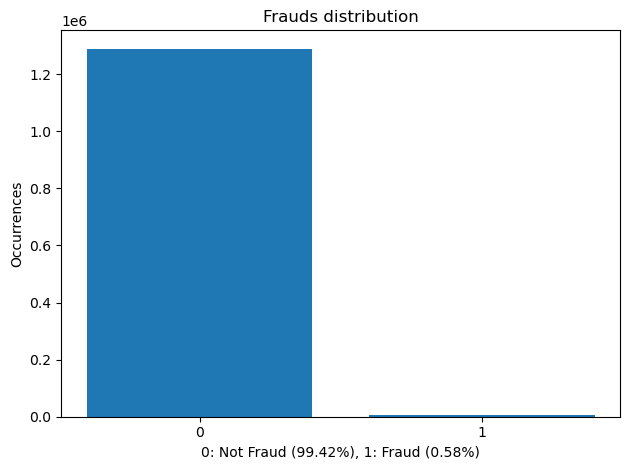

In [6]:
frauds=df["is_fraud"].value_counts()
fig,ax=plt.subplots()
ax.bar(frauds.index,frauds.values)
ax.set_xticks(frauds.index)
ax.set_title("Frauds distribution")
ax.set_xlabel(f"0: Not Fraud ({round(frauds[0]/frauds.sum()*100,2)}%), 1: Fraud ({round(frauds[1]/frauds.sum()*100,2)}%)")
ax.set_ylabel("Occurrences")

plt.tight_layout()
plt.show()

As we expect, the fraudolent transactions represent a negligible fraction of the dataset, suggesting that we are not addressing a normal binary classification problem but an anomaly detection problem. We can proceed with our EDA by inspecting `trans_date_trans_time` to check if there are any patterns in the fraudolent transactions time.

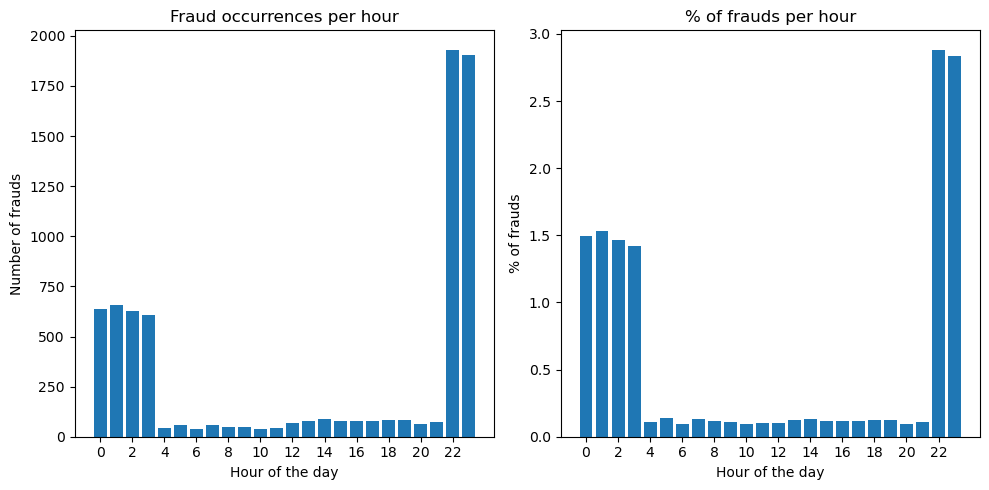

In [7]:
trans_hour=df["trans_date_trans_time"].dt.hour
fraud_hour=df["trans_date_trans_time"][df["is_fraud"]==1].dt.hour
trans_hour_counts=trans_hour.value_counts().sort_index()
fraud_hour_counts=fraud_hour.value_counts().sort_index()
perc_frauds=fraud_hour_counts/trans_hour_counts*100

fig,ax=plt.subplots(ncols=2, figsize=(10,5))
ax[0].bar(np.arange(24),fraud_hour_counts)
ax[0].set_xticks(np.arange(0,24,2))
ax[0].set_xlabel("Hour of the day")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Fraud occurrences per hour")

ax[1].bar(np.arange(24),perc_frauds)
ax[1].set_xticks(np.arange(0,24,2))
ax[1].set_xlabel("Hour of the day")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per hour")

plt.tight_layout()
plt.show()


Here we find our first important clue: the preferrd hour to commit frauds is between 22pm and 3am. This is proved by checking both the absolute recurrence of frauds and the percentage with respect to the total number of frauds. 

A more detailed handling of the time feature is done to check wheterer there are other patterns regarding the day of the week and the day of the month.

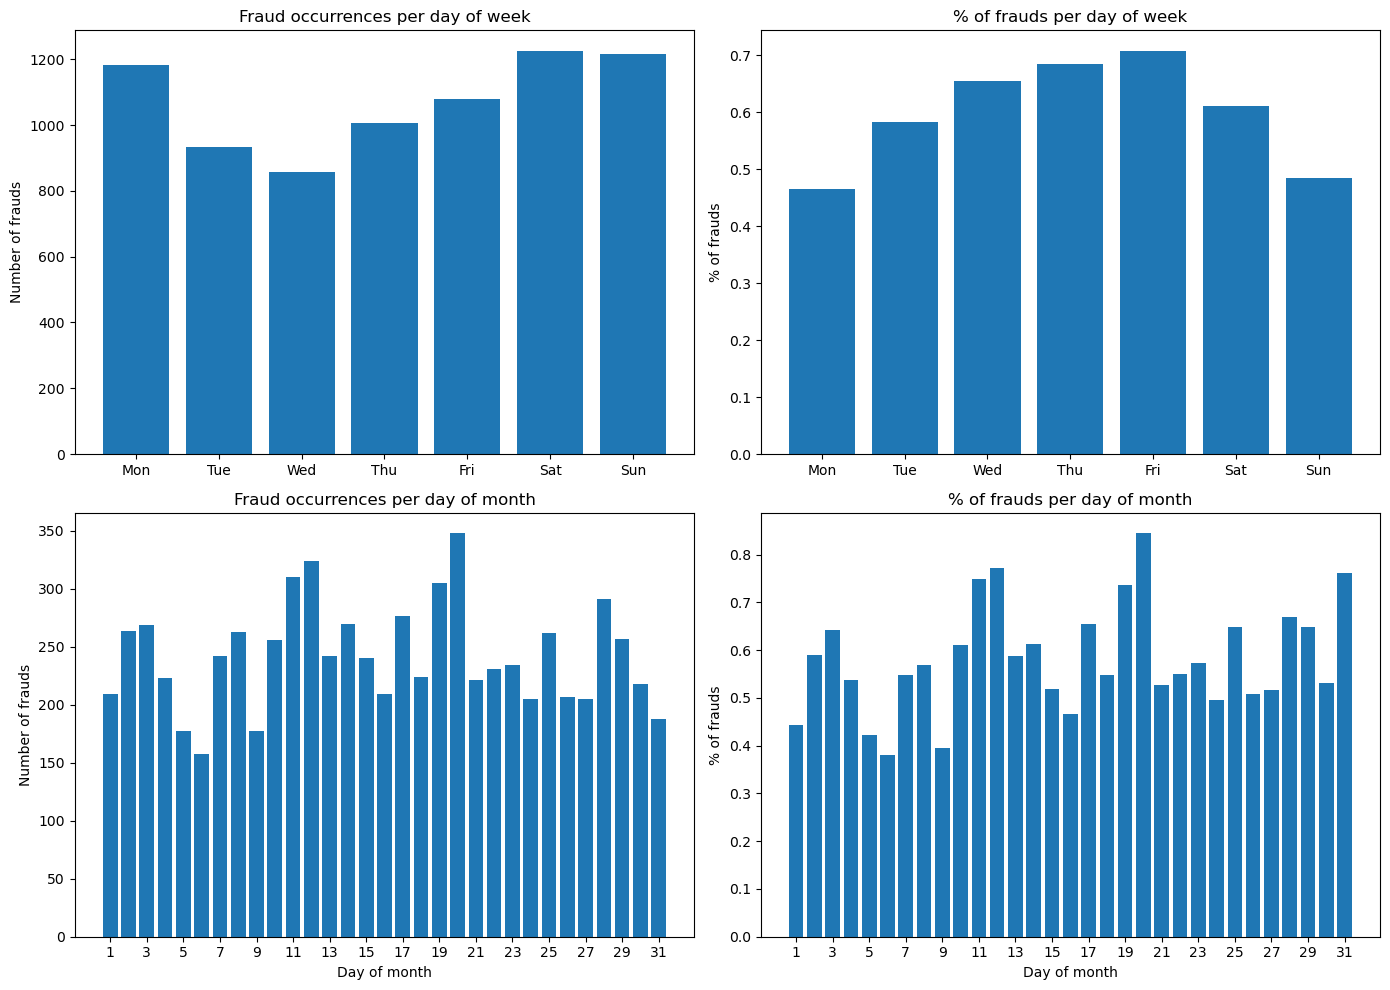

In [10]:
trans_dow = df["trans_date_trans_time"].dt.dayofweek
fraud_dow = df["trans_date_trans_time"][df["is_fraud"]==1].dt.dayofweek
trans_dow_counts = trans_dow.value_counts().sort_index()
fraud_dow_counts = fraud_dow.value_counts().sort_index()
perc_frauds_dow = (fraud_dow_counts / trans_dow_counts) * 100

dow = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

ax[0, 0].bar(trans_dow_counts.index, fraud_dow_counts)
ax[0, 0].set_xticks(range(7))
ax[0, 0].set_xticklabels(dow)
ax[0, 0].set_ylabel("Number of frauds")
ax[0, 0].set_title("Fraud occurrences per day of week")

ax[0, 1].bar(trans_dow_counts.index, perc_frauds_dow)
ax[0, 1].set_xticks(range(7))
ax[0, 1].set_xticklabels(dow)
ax[0, 1].set_ylabel("% of frauds")
ax[0, 1].set_title("% of frauds per day of week")

trans_dom = df["trans_date_trans_time"].dt.day
fraud_dom = df["trans_date_trans_time"][df["is_fraud"]==1].dt.day
trans_dom_counts = trans_dom.value_counts().sort_index()
fraud_dom_counts = fraud_dom.value_counts().sort_index()
perc_frauds_dom = (fraud_dom_counts / trans_dom_counts) * 100

ax[1, 0].bar(trans_dom_counts.index, fraud_dom_counts)
ax[1, 0].set_xticks(range(1, 32, 2))
ax[1, 0].set_xlabel("Day of month")
ax[1, 0].set_ylabel("Number of frauds")
ax[1, 0].set_title("Fraud occurrences per day of month")

ax[1, 1].bar(trans_dom_counts.index, perc_frauds_dom)
ax[1, 1].set_xticks(range(1, 32, 2))
ax[1, 1].set_xlabel("Day of month")
ax[1, 1].set_ylabel("% of frauds")
ax[1, 1].set_title("% of frauds per day of month")


plt.tight_layout()
plt.show()

We find out that by scoping out the granularity of the time dimension we do not find valuable informations.

We can now proceed to analyze the `category` of the shop were frauds are committed.

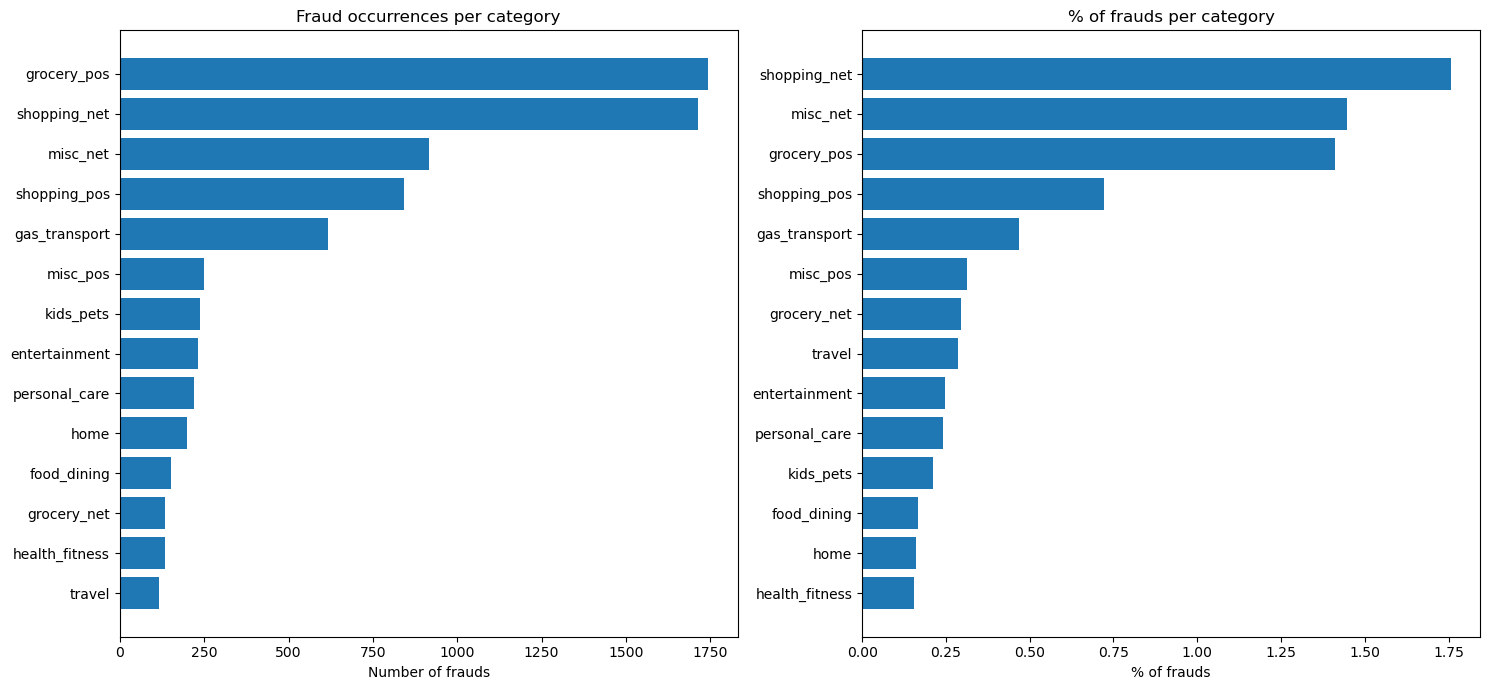

In [13]:
trans_cat = df["category"].value_counts()
fraud_cat = df[df["is_fraud"] == 1]["category"].value_counts()
perc_frauds_cat = (fraud_cat / trans_cat * 100).sort_values(ascending=True)
fraud_cat_sorted = fraud_cat.sort_values(ascending=True)

fig, ax = plt.subplots(ncols=2, figsize=(15, 7))

ax[0].barh(fraud_cat_sorted.index, fraud_cat_sorted.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Fraud occurrences per category")

ax[1].barh(perc_frauds_cat.index, perc_frauds_cat.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("% of frauds per category")

plt.tight_layout()
plt.show()

Here we find another importand signal for our analysis: even though the most represented categories are clearly the most common such as groceries and shopping, the percentage of frauds is dominated by online transactions (categories ending with the *_net* suffix). 

We proceed with our EDA by analyzing the `amt` feature, representing the amount of dollars of each transaction.

Stats legit transactions
count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64

Stats frauds
count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64


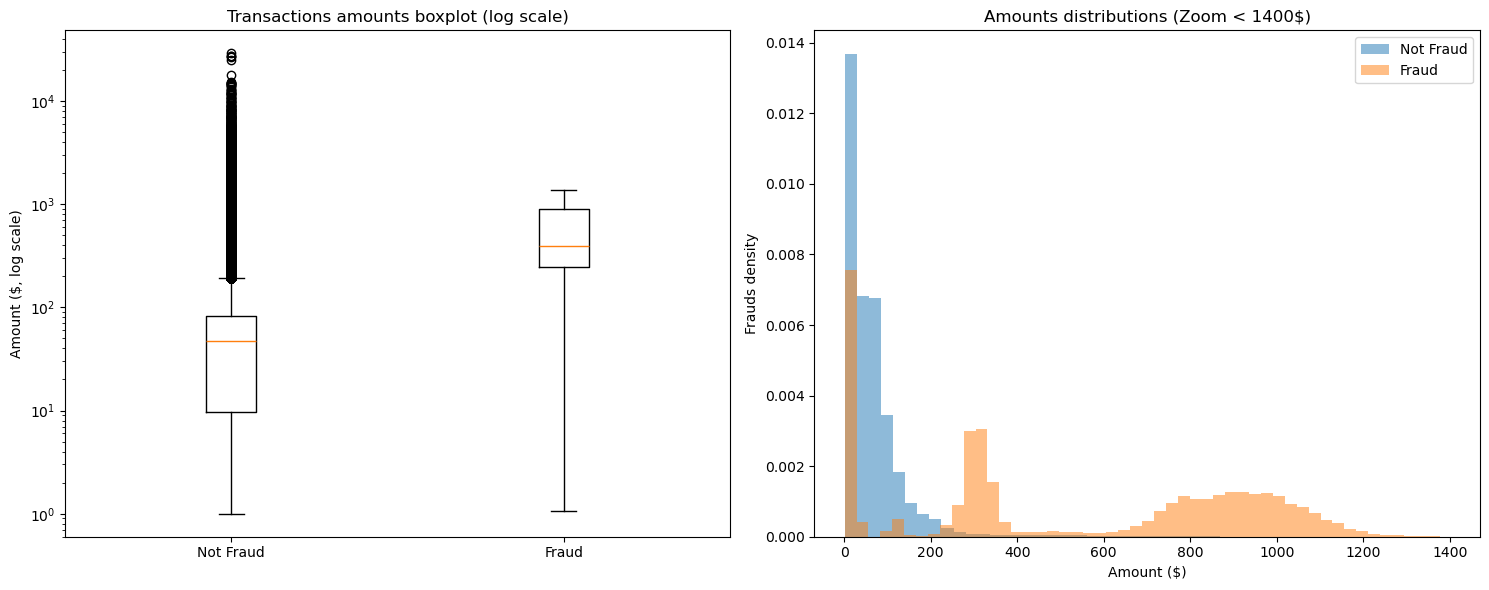

In [58]:
print("Stats legit transactions")
print(df[df['is_fraud'] == 0]['amt'].describe())
print("\nStats frauds")
print(df[df['is_fraud'] == 1]['amt'].describe())

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].boxplot([df[df["is_fraud"]==0]["amt"], df[df["is_fraud"]==1]["amt"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log") 
ax[0].set_ylabel("Amount ($, log scale)")
ax[0].set_title("Transactions amounts boxplot (log scale)")

ax[1].hist(df[(df["is_fraud"]==0) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[(df["is_fraud"]==1) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Amount ($)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Amounts distributions (Zoom < 1400$)")
ax[1].legend()

plt.tight_layout()
plt.show()

The combination of the printed statistics, the boxplots and the empirical distributions gives us another huge hint: the normal transactions are almost all in the range of tens of dollars with few high transactions (normal people might buy expensive things once in a while). Fraudolent transactions exhibit a different behavior: scammers usualy do some small transactions to check wheter the card is functioning and then they make larger transactions in the range of hundreds of dollars.

We are now interested in analyzing if the age of the people (`dob`) is a significant factor in the scammer activity.

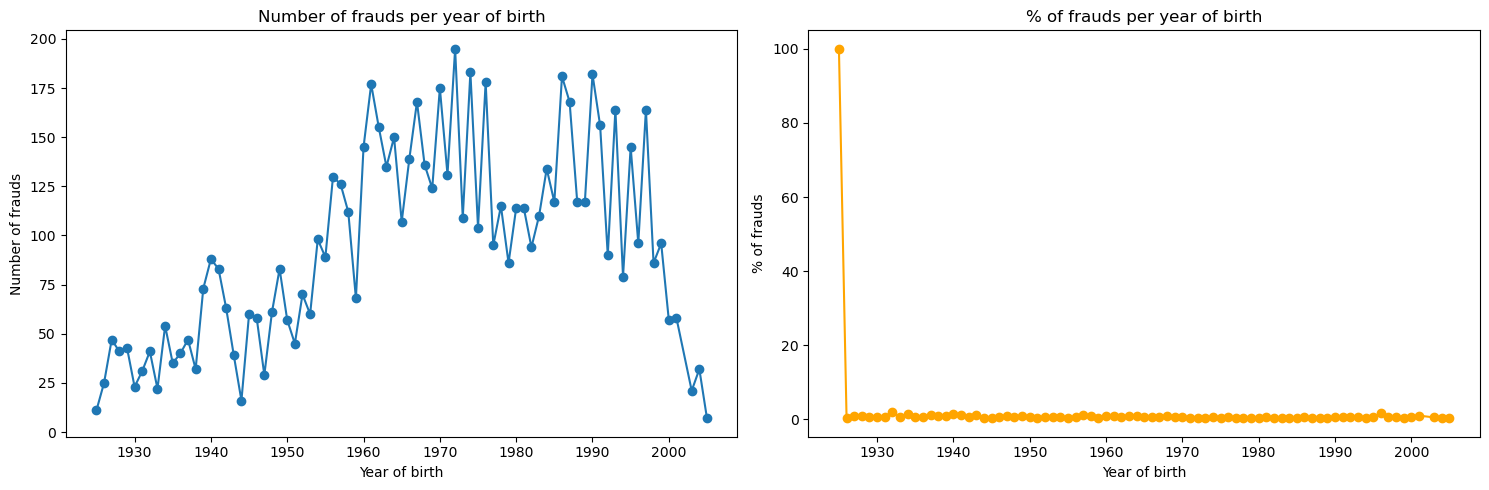

In [29]:
trans_yob = df["dob"].dt.year
fraud_yob = df[df["is_fraud"] == 1]["dob"].dt.year
trans_yob_counts = trans_yob.value_counts().sort_index()
fraud_yob_counts = fraud_yob.value_counts().sort_index()
perc_frauds_yob = (fraud_yob_counts / trans_yob_counts) * 100

fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].plot(fraud_yob_counts.index, fraud_yob_counts.values, marker='o', linestyle='-')
ax[0].set_xlabel("Year of birth")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Number of frauds per year of birth")


ax[1].plot(perc_frauds_yob.index, perc_frauds_yob.values, marker='o', linestyle='-', color='orange')
ax[1].set_xlabel("Year of birth")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per year of birth")


plt.tight_layout()
plt.show()

In [41]:
df[df["dob"].dt.year==1925][["cc_num","is_fraud"]].value_counts()

cc_num            is_fraud
4492677353108006  1           11
Name: count, dtype: int64

Here we have double checked a phenomena that might have confused our analysis: first of all we notice that the absolute number of frauds with respect to the date of birth is higher for the population born roughly between 1960 and 2000 (since the dataset analyzes transactions ranging from early 2019 to late 2020 this is just the active population). The percentage of frauds in this case does not exhibit clear patterns with the exception for the year 1925 for which all transactions seem to be fraudolent. A more detailted check tells us that this is just due to the fact that there is a single person born in 1925 whose card have been stolen to make a small amount of fraudolent transactions. 

We can proceed by checking wheter there is any correlation between the residence location of the owner of the card (`lat`, `long`) and the location of the shop where the fraud has been committed (`lat_merch`, `long_merch`) 

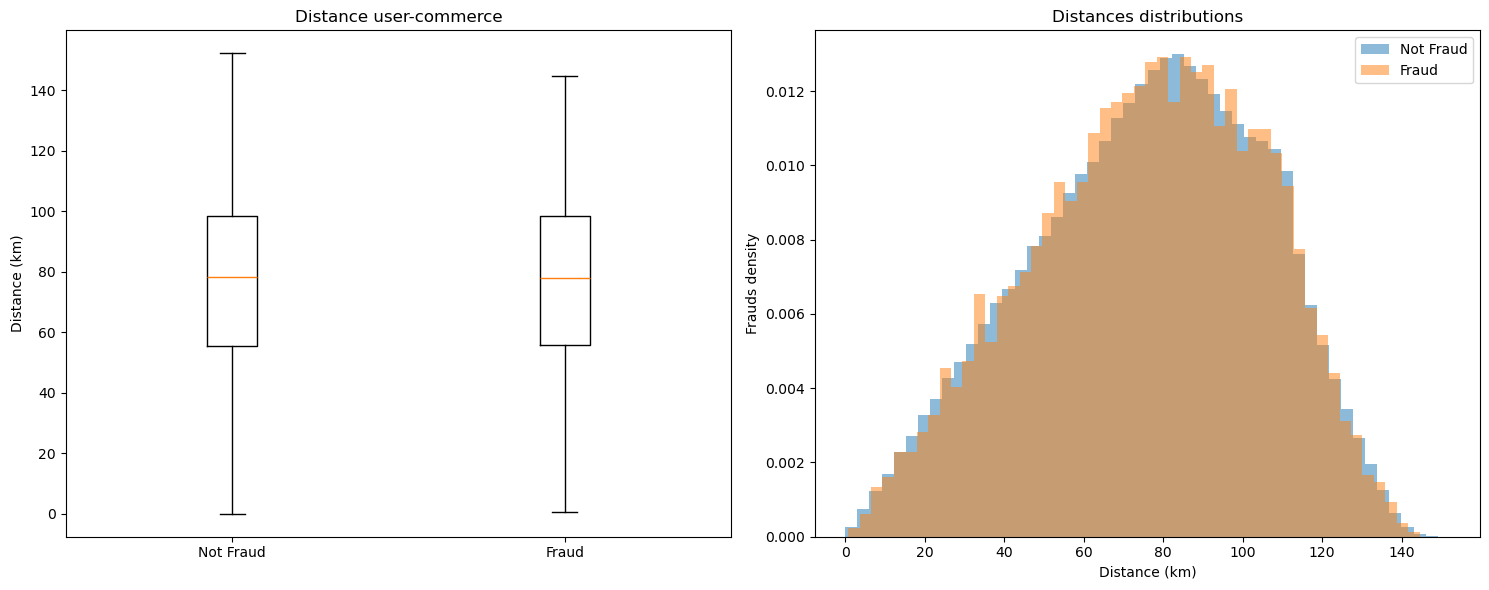

In [55]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    d=R*c
    return d

dist_km = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].boxplot([dist_km[df["is_fraud"]==0], dist_km[df["is_fraud"]==1]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_ylabel("Distance (km)")
ax[0].set_title("Distance user-commerce")

ax[1].hist(dist_km[df["is_fraud"]==0], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(dist_km[df["is_fraud"]==1], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Distance (km)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Distances distributions")
ax[1].legend()

plt.tight_layout()
plt.show()

To accomplish this goal we took advantage of a function that compute the *Haversine distance*: both the boxplots and the empirical distributions show us that the geographical coordinates play no role in our analysis since they are almost overlapping.

We can know check wheter the `gender` of the owner of the card is somehow interesting.

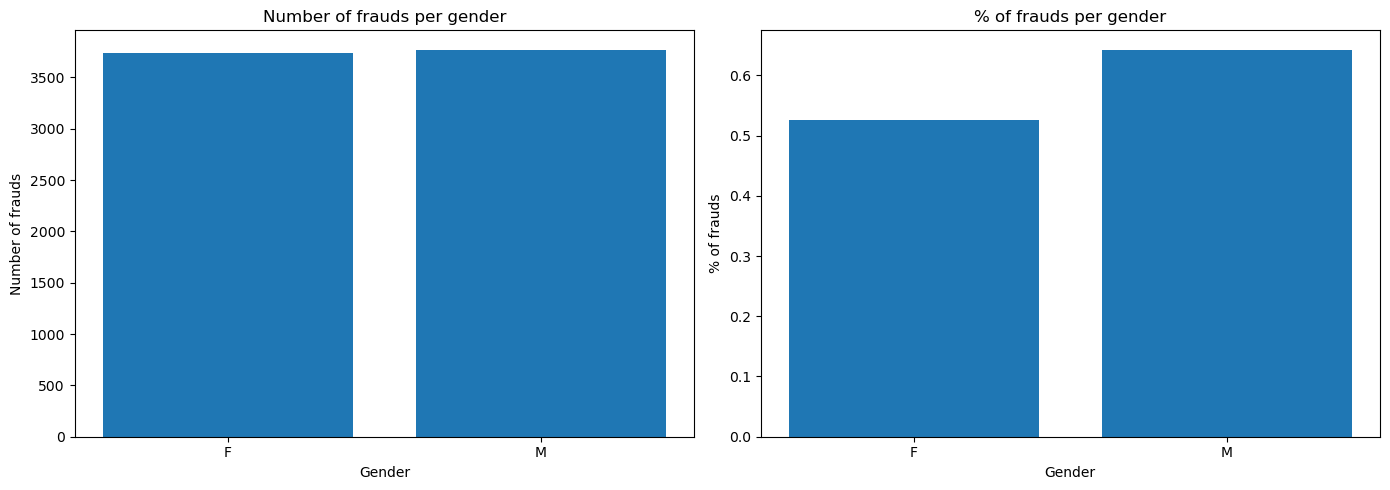

In [52]:
trans_gender = df['gender'].value_counts().sort_index()
fraud_gender = df[df['is_fraud']==1]['gender'].value_counts().sort_index()
perc_gender = (fraud_gender / trans_gender) * 100

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(fraud_gender.index, fraud_gender.values)
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Number of frauds per gender")

ax[1].bar(perc_gender.index, perc_gender.values)
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per gender")

plt.tight_layout()
plt.show()

Clearly this information is completely useless.

Now we want to analyze wheter the population (`city_pop`) of a certain city is useful to predict the frauds.

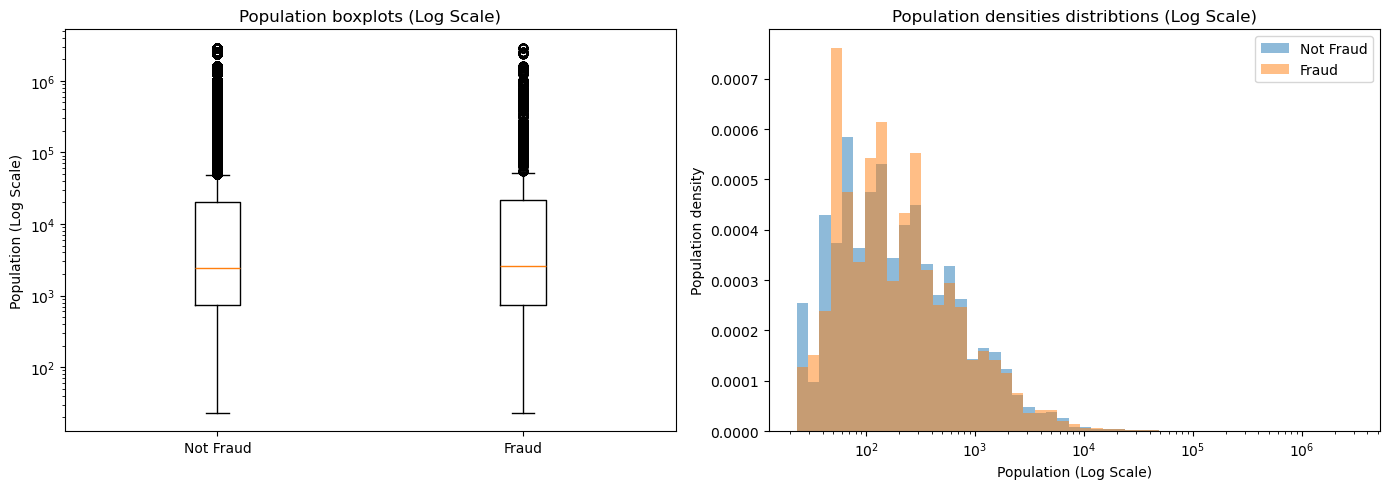

In [60]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([df[df["is_fraud"]==0]["city_pop"], df[df["is_fraud"]==1]["city_pop"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log")
ax[0].set_ylabel("Population (Log Scale)")
ax[0].set_title("Population boxplots (Log Scale)")

bins = np.logspace(np.log10(df['city_pop'].min()), np.log10(df['city_pop'].max()), 50)
ax[1].hist(df[df["is_fraud"]==0]["city_pop"], bins=bins, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[df["is_fraud"]==1]["city_pop"], bins=bins, alpha=0.5, label="Fraud", density=True)
ax[1].set_xscale("log")
ax[1].set_xlabel("Population (Log Scale)")
ax[1].set_ylabel("Population density")
ax[1].set_title("Population densities distribtions (Log Scale)")
ax[1].legend()

plt.tight_layout()
plt.show()

Once again, both the boxplots and the distributions are almost overlapping meaning that no information can be directly extracted.

To finish our analysis we want to check different levels of geographical granularity to check wheter certain `states` are particularly subject to frauds. We avoid scoping in the granularity of the geographical coordinates since the dimensionality would only give us trouble.

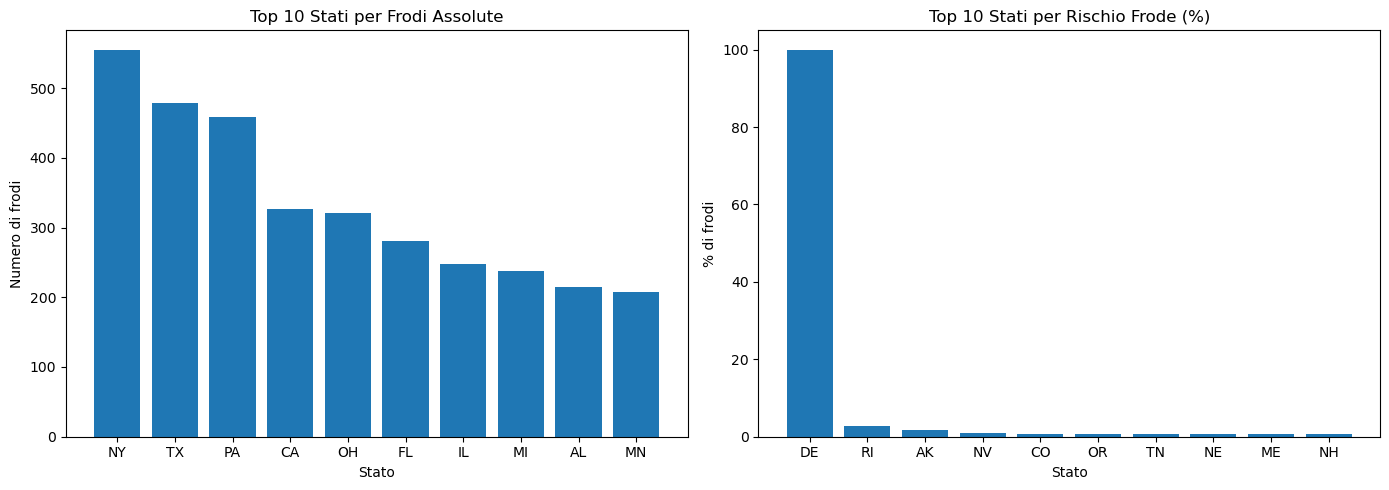

In [ ]:
trans_state = df['state'].value_counts()
fraud_state = df[df['is_fraud']==1]['state'].value_counts()

top10_abs = fraud_state.sort_values(ascending=False).head(10)
perc_state = (fraud_state / trans_state * 100).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(top10_abs.index, top10_abs.values)
ax[0].set_xlabel("Stato")
ax[0].set_ylabel("Numero di frodi")
ax[0].set_title("Top 10 Stati per Frodi Assolute")

ax[1].bar(perc_state.index, perc_state.values)
ax[1].set_xlabel("Stato")
ax[1].set_ylabel("% di frodi")
ax[1].set_title("Top 10 Stati per Rischio Frode (%)")

plt.tight_layout()
plt.show()

In [64]:
df[df['state']=='DE'][["cc_num","state","is_fraud"]].value_counts()

cc_num            state  is_fraud
6011826317034777  DE     1           9
Name: count, dtype: int64

In absolute terms we notice that there is no state where the number of frauds is significantly higher than the others. In relative terms the state of Delaware (DE) seem to give us some information but a further analysis show us that a single credit card has been scammed in Delaware to make a small amount of fraudolent transactions. 